# Exploring CNNs Through Image Classification
 #### A summative laboratory exercise in partial fulfillment of the requirements for the course CSELEC2C: Machine Learning
 Prepared by Raul Sebastien B. Baldemoro and Jan Vincent G. Elleazar <br> Department of Computer Science, College of Information and Computing Sciences, University of Santo Tomas, City of Manila, Philippines
 <br><br>
 ***

# Overview of the Summative Laboratory Exercise
The main objective of this exercise is to familiarize ourselves with the tools used to build convolutional neural networks and applying the concepts learned in our CSELEC2C lectures into practical uses. Furthermore, the goal is **not to get the best performance** but rather to **explore how various modifications of the convolutional neural network and changes in hyperparameters affect the performance of the model.** Experiments and exploration on various aspects of the convolutional neural network are being encouraged. However, **it is important to identify the reason behind our certain decisions** in our architecture and **test it out empirically.**

For our task, we are to create convolutional neural networks for the hair types dataset. The dataset contains images with respect to different hair types. The main goal for this exercise is for us to build a convolutional neural network from scratch and to experiment on its hyperparameters.  Note that we are tasked to build your convolutional neural network on our own. **Which means that we are not allowed to use pre-trained networks and commonly defined architectures for this task.**

The documentation for this exercise is included in the same directory. 

**Prerequisites:**
- TensorFlow
- NumPy
- Pandas
- Matplotlib
- OpenCV
<br><br>
***

# Given Demonstration of the Summative Laboratory Exercise
This section presents the given demonstration of the exercise. This will be the foundation of our experimentation and exploration of the CNN architecture.
## Part 1: Checking the Dataset
**Image Checking:** Check if all files are valid

In [1]:
from pathlib import Path
import imghdr
import os

data_dir = "hair_types"
image_extensions = [".png", ".jpg"]  # add there all your images file extensions

img_type_accepted_by_tf = ["bmp", "gif", "jpeg", "png"]
for filepath in Path(data_dir).rglob("*"):
    if filepath.suffix.lower() in image_extensions:
        img_type = imghdr.what(filepath)
        if img_type is None:
            print(f"{filepath} is not an image")
            os.remove(filepath)
        elif img_type not in img_type_accepted_by_tf:
            print(f"{filepath} is a {img_type}, not accepted by TensorFlow")
            os.remove(filepath)

## Part 2: Using a DataLoader for Data Loading

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size, 
    labels='inferred',
    label_mode='categorical'
)

/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 981 files belonging to 3 classes.
Using 785 files for training.
Found 981 files belonging to 3 classes.
Using 196 files for validation.


## Part 3: Visualizing the Data

2025-05-01 11:36:42.443617: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


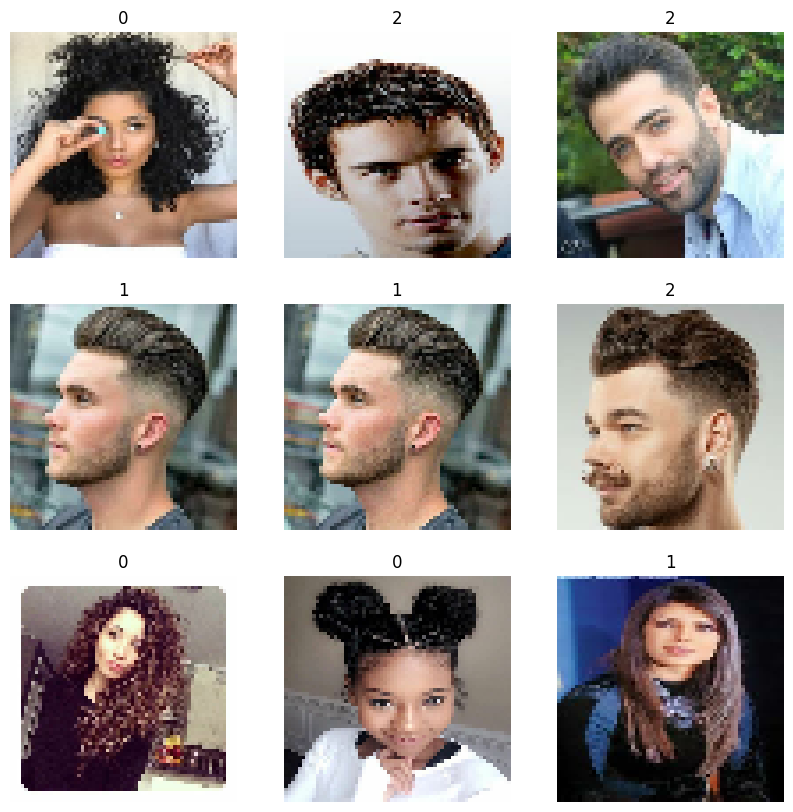

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(np.argmax(labels[i])))
        plt.axis("off")
plt.show()

## Part 4: Sample Model

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test.png', show_shapes=True)

epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.3703 - loss: 1.0981 - val_accuracy: 0.2857 - val_loss: 1.1651
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.3886 - loss: 1.0905 - val_accuracy: 0.3827 - val_loss: 1.0801
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.4307 - loss: 1.0633 - val_accuracy: 0.4082 - val_loss: 1.0830
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.4540 - loss: 1.0530 - val_accuracy: 0.4133 - val_loss: 1.0924
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.4613 - loss: 1.0301 - val_accuracy: 0.4184 - val_loss: 1.0494
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.4838 - loss: 1.0101 - val_accuracy: 0.3980 - val_loss: 1.0576
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.4621 - loss: 0.9913 - val_accuracy: 0.4184 - val_loss: 1.0427
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.4899 - loss: 0.9875 - val_accuracy: 0.

## Part 5: Predictions for Images

In [5]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
This image is 0.88 percent curly hair, 0.11 percent straight hair, and 0.01 percent wavy hair.


***
# Experimentation and Exploration
This section presents our experiments that we conducted to learn more about the CNN architectures and hyperparamteters. Furthermore, we will test diverse combinations in modifying the architecture and fine-tuning the hyperparameters of CNN to see the how those combinations affect the performance of CNN in classifying hair types. Each experiments are listed below with its corresponding sub-experiments:
- Experiment #1: Other Preprocessing methods for Images
    - Experiment 1.1: Consistent Image Dimensions
    - Experiment 1.2: Pixel Intensity Normalization
    - Experiment 1.3: Filters and Edge Sharpening   
- Experiment #2: Implementation of Different Types of Pooling
    - Experiment 2.1: Max Pooling
    - Experiment 2.2: Average Pooling
    - Experiment 2.3: Global Max Pooling
    - Experiment 2.4: Global Average Pooling
- Experiment #3: Changing Number of Filters
    - Experiment 3.1: filters 2, 4, 8
    - Experiment 3.2: filters 4, 6, 8
    - Experiment 3.3: filters 8, 16, 32
    - Experiment 3.4: filters 16, 32, 64
    - Experiment 3.5: filters 32, 64, 128
    - Experiment 3.6: filters 16, 16, 16
- Experiment #4: Changing Kernel Size
    - Experiment 4.1: Kernel Size (3,3), (5,5), (9,9)
    - Experiment 4.2: Kernel Size (3,3), (3,3), (3,3)
    - Experiment 4.3: Kernel Size (5,5), (5,5), (5,5)
    - Experiment 4.4: Kernel Size (7,7), (5,5), (3,3)
- Experiment #5: Changing Learning Rate
    - Experiment 5.1 Learning Rate 1e-2
    - Experiment 5.2 Learning Rate 1e-4
    - Experiment 5.3 Learning Rate 1e-5

## Experiment #1: Other Preprocessing methods for Images

This experiment explores other preprocessing techniques to enhance the model's accuracy metric just from the quality of the images itself. The following sub-experiments are the other prepreocessing techniques conducted:
- Experiment 1.1: Consistent Image Dimensions
- Experiment 1.2: Pixel Intensity Normalization
- Experiment 1.3: Filters and Edge Sharpening

### Experiment 1.1: Consistent Image Dimensions
This experiment utilizes OpenCV for image resizing. The width of the images were resized into 224 pixels while maintaining the aspect ration of the images. Cropping the images was not considered due to the nature of some images where the subject (hair) is not at the center of the image.

In [ ]:
import cv2 as cv

data_dir = "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/hair_types"  # Input directory
output_dir = "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/resized_hair_types"  # Output directory for resized images
new_width = 224

# Create the output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for root, _, files in os.walk(data_dir):
    for filename in files:
        filepath = os.path.join(root, filename)
        try:
            # Read the image using the full file path
            img = cv.imread(filepath)

            # Check if the image was loaded successfully
            if img is not None:
                # Resize the image
                # Get the original dimensions
                original_height, original_width = img.shape[:2]
                aspect_ratio = new_width / original_width
                new_height = int(original_height * aspect_ratio)  # Compute height based on aspect ratio
                resized_image = cv.resize(img, (new_width, new_height))

                # Construct the output file path.  Preserve directory structure.
                # Get the relative path from the original data_dir
                relative_path = os.path.relpath(filepath, data_dir)
                # Create the full output path
                output_filepath = os.path.join(output_dir, relative_path)

                # Ensure the output directory exists
                output_dir_for_file = os.path.dirname(output_filepath)  # Get directory part
                if not os.path.exists(output_dir_for_file):
                    os.makedirs(output_dir_for_file)

                # Save the resized image
                cv.imwrite(output_filepath, resized_image)
                print(f"Resized and saved: {output_filepath}")

            else:
                print(f"Error loading image: {filepath}")

        except Exception as e:
            print(f"An error occurred with {filepath}: {str(e)}")

Error loading image: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/hair_types/.DS_Store
Resized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/resized_hair_types/Wavy_Hair/images282.jpg
Resized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/resized_hair_types/Wavy_Hair/images26.jpg
Resized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/resized_hair_types/Wavy_Hair/images32.jpg
Resized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/resized_hair_types/Wavy_Hair/long-hairstyles-for-indian-men-6(1).jpg
Resized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/resized_hair_types/Wavy_Hair/image3(1).jpeg
Resized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/resized_hair_types/Wavy_Hair/images308.jpg
Resized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHIN

#### Experiment 1.1 Data Loading, Model Training, and Model Evaluation

Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.


2025-05-05 10:10:25.148420: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


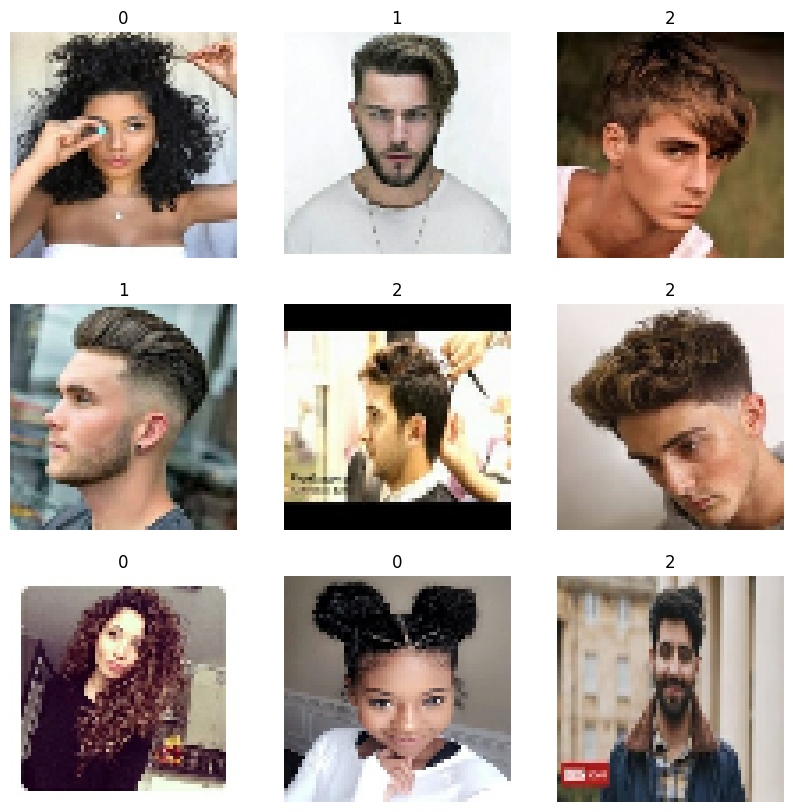

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.2967 - loss: 1.1001 - val_accuracy: 0.2857 - val_loss: 1.0995
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3516 - loss: 1.0983 - val_accuracy: 0.2857 - val_loss: 1.0998
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.3161 - loss: 1.0986 - val_accuracy: 0.2857 - val_loss: 1.0992
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.3564 - loss: 1.0917 - val_accuracy: 0.2857 - val_loss: 1.0960
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.3722 - loss: 1.0735 - val_accuracy: 0.4031 - val_loss: 1.0841
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.4446 - loss: 1.0524 - val_accuracy: 0.4184 - val_loss: 1.0748
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.4891 - loss: 1.0452 - val_accuracy: 0.4184 - val_loss: 1.0649
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.4841 - loss: 1.0309 - val_accuracy: 0.4388 - 

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt
import numpy as np

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "resized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "resized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size, 
    labels='inferred',
    label_mode='categorical'
)

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(np.argmax(labels[i])))
        plt.axis("off")
plt.show()

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test.png', show_shapes=True)

epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)

#### Experiment 1.1 Evaluation Metrics Visualization

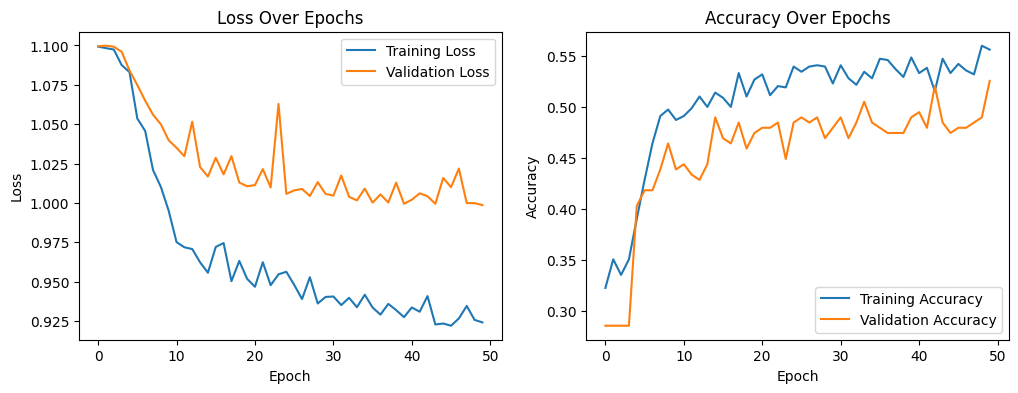

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


2025-05-05 10:12:51.298443: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


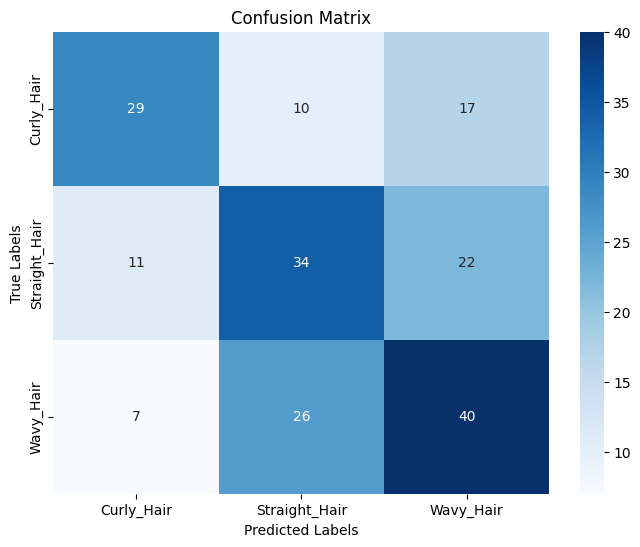

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.62      0.52      0.56        56
Straight_Hair       0.49      0.51      0.50        67
    Wavy_Hair       0.51      0.55      0.53        73

     accuracy                           0.53       196
    macro avg       0.54      0.52      0.53       196
 weighted avg       0.53      0.53      0.53       196



In [4]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

### Experiment 1.2: Pixel Intensity Normalization
This experiment utilizes NumPy to convert the image data into float32 and then divided into 255 so the pixel intensities will be scaled to the range [0.1].

In [5]:
import numpy as np

data_dir = "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/resized_hair_types"  # Input directory
output_dir = "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types"  # Output directory for normalized images

# Create the output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for root, _, files in os.walk(data_dir):
    for filename in files:
        filepath = os.path.join(root, filename)
        try:
            # Read the image using the full file path
            img = cv.imread(filepath)

            # Check if the image was loaded successfully
            if img is not None:
                # Convert to float32 for normalization
                img_normalized = img.astype(np.float32)

                # Normalize pixel values to the range [0, 1]
                img_normalized = img_normalized / 255.0

                # Construct the output file path.  Preserve directory structure.
                # Get the relative path from the original data_dir
                relative_path = os.path.relpath(filepath, data_dir)
                # Create the full output path
                output_filepath = os.path.join(output_dir, relative_path)

                # Ensure the output directory exists
                output_dir_for_file = os.path.dirname(output_filepath)  # Get directory part
                if not os.path.exists(output_dir_for_file):
                    os.makedirs(output_dir_for_file)

                # Save the normalized image
                cv.imwrite(output_filepath, (img_normalized * 255).astype(np.uint8))  # Convert back to uint8 for saving
                print(f"Normalized and saved: {output_filepath}")

            else:
                print(f"Error loading image: {filepath}")

        except Exception as e:
            print(f"An error occurred with {filepath}: {str(e)}")

Normalized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types/Wavy_Hair/images282.jpg
Normalized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types/Wavy_Hair/images26.jpg
Normalized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types/Wavy_Hair/images32.jpg
Normalized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types/Wavy_Hair/long-hairstyles-for-indian-men-6(1).jpg
Normalized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types/Wavy_Hair/image3(1).jpeg
Normalized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types/Wavy_Hair/images308.jpg
Normalized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types/Wavy_Hair/images320.jpg
Normalize

#### Experiment 1.2 Data Loading, Model Training, and Model Evaluation

/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.


2025-05-05 10:33:55.790596: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


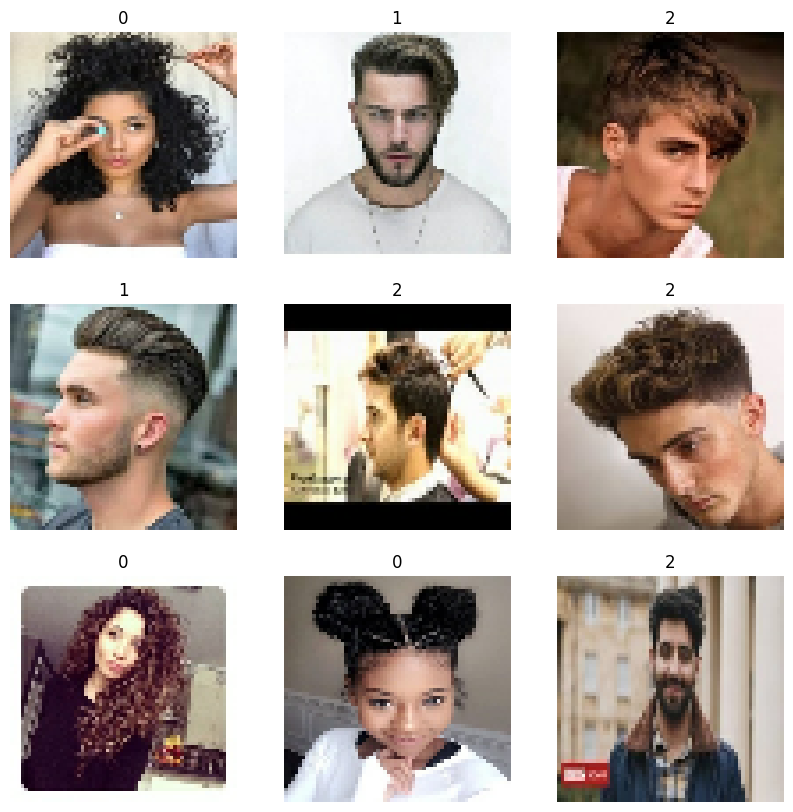

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.3306 - loss: 1.1013 - val_accuracy: 0.2857 - val_loss: 1.1004
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.3516 - loss: 1.0982 - val_accuracy: 0.2857 - val_loss: 1.1008
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.3205 - loss: 1.0995 - val_accuracy: 0.2857 - val_loss: 1.1027
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.3571 - loss: 1.0973 - val_accuracy: 0.2857 - val_loss: 1.0988
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.3448 - loss: 1.0983 - val_accuracy: 0.2857 - val_loss: 1.0998
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.3453 - loss: 1.0968 - val_accuracy: 0.2857 - val_loss: 1.0944
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3817 - loss: 1.0568 - val_accuracy: 0.3469 - val_loss: 1.0876
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.4271 - loss: 1.0497 - val_accuracy: 0.4439 - v

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt
import numpy as np

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size, 
    labels='inferred',
    label_mode='categorical'
)

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(np.argmax(labels[i])))
        plt.axis("off")
plt.show()

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test.png', show_shapes=True)

epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)

#### Experiment 1.2 Evaluation Metrics Visualization

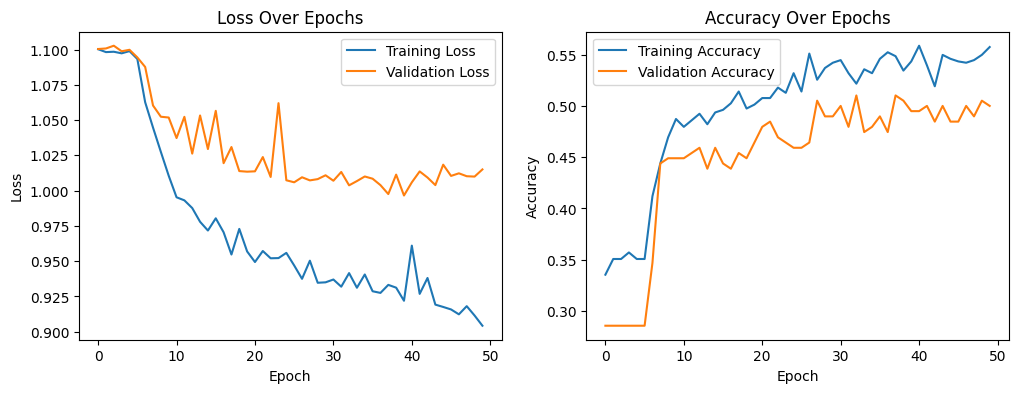

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


2025-05-05 10:35:50.906681: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


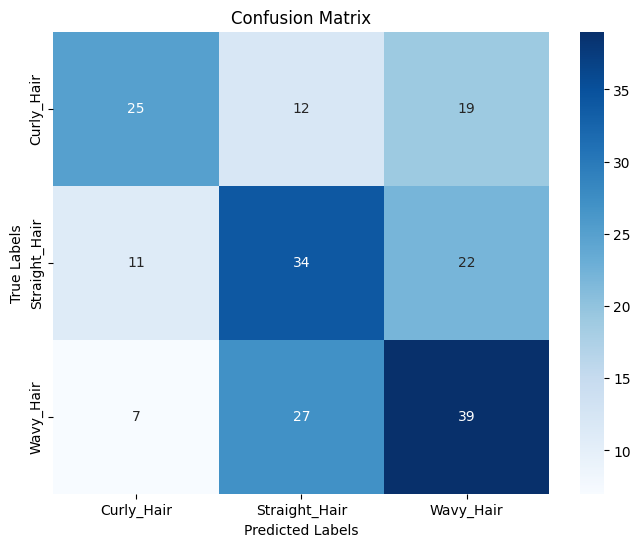

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.58      0.45      0.51        56
Straight_Hair       0.47      0.51      0.49        67
    Wavy_Hair       0.49      0.53      0.51        73

     accuracy                           0.50       196
    macro avg       0.51      0.50      0.50       196
 weighted avg       0.51      0.50      0.50       196



In [2]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

### Experiment 1.3: Filters and Edge Sharpening
This experiment uses Gaussian Blur and Laplacian Filter. Gaussian Blur is used for image smoothening and noise reduction while Laplacian Filter is used for edge sharpening.

In [6]:
data_dir = "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types"  # Input directory
output_dir = "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/filtered_hair_types"  # Output directory

# Create the output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for root, _, files in os.walk(data_dir):
    for filename in files:
        filepath = os.path.join(root, filename)
        try:
            # Read the image using the full file path
            img = cv.imread(filepath)

            # Check if the image was loaded successfully
            if img is not None:
                # Apply Gaussian Blur
                img_blurred = cv.GaussianBlur(img, (5, 5), 0)  # Kernel size 5x5, sigma = 0

                # Apply Laplacian filter
                img_laplacian = cv.Laplacian(img_blurred, cv.CV_32F)

                # Construct the output file paths.
                relative_path = os.path.relpath(filepath, data_dir)

                # Output filepath
                output_filepath = os.path.join(output_dir, relative_path)

                # Ensure the output directory exists
                output_dir_for_file = os.path.dirname(output_filepath)
                if not os.path.exists(output_dir_for_file):
                    os.makedirs(output_dir_for_file)

                # Need to handle the Laplacian image differently before saving
                # 1. Find min and max
                min_val = np.min(img_laplacian)
                max_val = np.max(img_laplacian)

                # 2. Scale to 0-255
                if (max_val - min_val) != 0:
                  img_laplacian_scaled = (255 * (img_laplacian - min_val) / (max_val - min_val)).astype(np.uint8)
                else:
                   img_laplacian_scaled = np.zeros_like(img_laplacian, dtype=np.uint8)

                cv.imwrite(output_filepath, img_laplacian_scaled)

                print(f"Processed and saved: {output_filepath}")

            else:
                print(f"Error loading image: {filepath}")

        except Exception as e:
            print(f"An error occurred with {filepath}: {str(e)}")

Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/filtered_hair_types/Wavy_Hair/images282.jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/filtered_hair_types/Wavy_Hair/images26.jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/filtered_hair_types/Wavy_Hair/images32.jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/filtered_hair_types/Wavy_Hair/long-hairstyles-for-indian-men-6(1).jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/filtered_hair_types/Wavy_Hair/image3(1).jpeg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/filtered_hair_types/Wavy_Hair/images308.jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/filtered_hair_types/Wavy_Hair/images320.jpg
Processed and saved: /Users/jj

#### Experiment 1.3 Data Loading, Model Training, and Model Evaluation

/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.


2025-05-05 10:36:35.700735: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


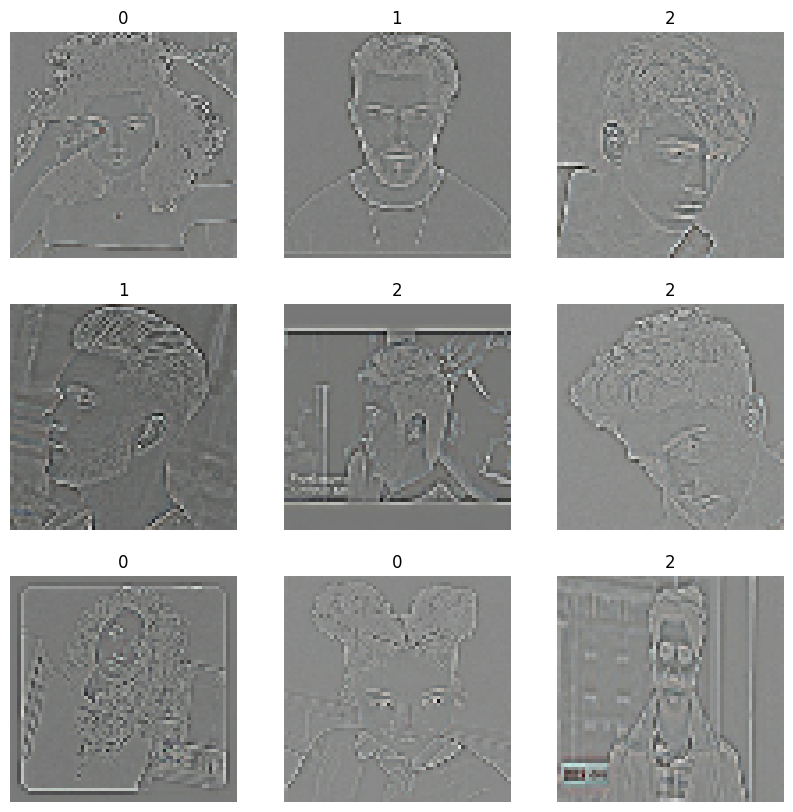

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.3378 - loss: 1.1008 - val_accuracy: 0.2857 - val_loss: 1.0996
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.3516 - loss: 1.0983 - val_accuracy: 0.2857 - val_loss: 1.1003
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3205 - loss: 1.0994 - val_accuracy: 0.2857 - val_loss: 1.1007
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.3564 - loss: 1.0979 - val_accuracy: 0.2857 - val_loss: 1.1017
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.3448 - loss: 1.0985 - val_accuracy: 0.2857 - val_loss: 1.1013
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3453 - loss: 1.0986 - val_accuracy: 0.2857 - val_loss: 1.1025
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3517 - loss: 1.0982 - val_accuracy: 0.2857 - val_loss: 1.1023
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.3259 - loss: 1.1003 - val_accuracy: 0.2857 - v

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "filtered_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "filtered_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size, 
    labels='inferred',
    label_mode='categorical'
)

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(np.argmax(labels[i])))
        plt.axis("off")
plt.show()

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test.png', show_shapes=True)

epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)

#### Experiment 1.3 Evaluation Metrics Visualization

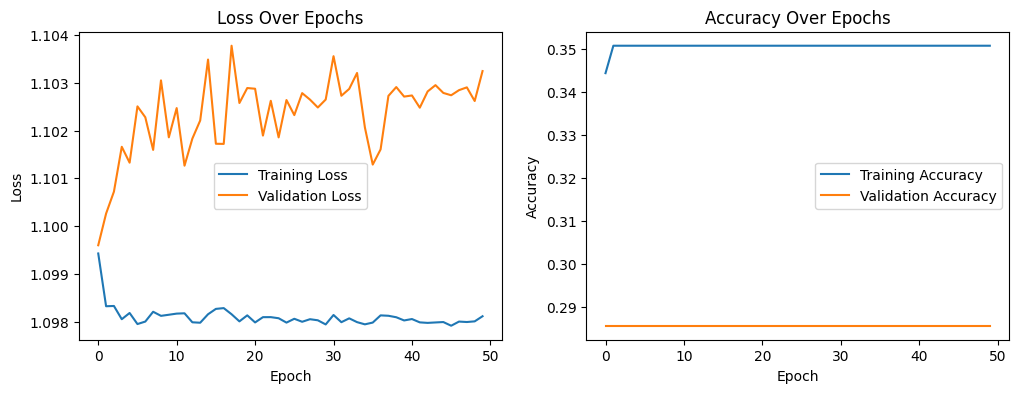

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


2025-05-05 10:38:35.225529: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


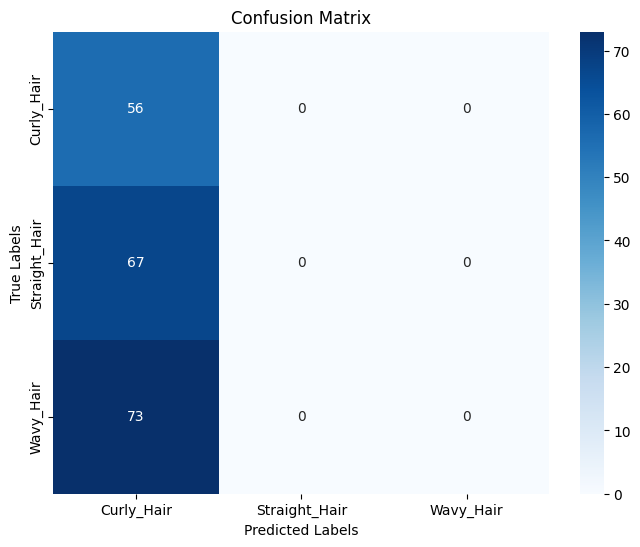

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.29      1.00      0.44        56
Straight_Hair       0.00      0.00      0.00        67
    Wavy_Hair       0.00      0.00      0.00        73

     accuracy                           0.29       196
    macro avg       0.10      0.33      0.15       196
 weighted avg       0.08      0.29      0.13       196



/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

In [2]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

## Experiment #2: Implementation of Different Types of Pooling

This experiment explores the implementation of different types of pooling. The normalized hair types dataset will be used for this experiment since the sample model performed better in the said dataset. The following sub-experiments are the implementation of different types of pooling. 
- Experiment 2.1: Max Pooling
- Experiment 2.2: Average Pooling
- Experiment 2.3: Global Max Pooling
- Experiment 2.4: Global Average Pooling

### Experiment 2.1: Max Pooling
This experiment uses MaxPooling2D in Keras. A Max Pooling layer was added on each Conv2D layer.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2,2))) # Added Max Pooling

model.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2,2))) # Added Max Pooling

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2,2))) # Added Max Pooling

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_with_pooling.png', show_shapes=True) #Changed filename
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)

/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.3602 - loss: 1.0922 - val_accuracy: 0.3878 - val_loss: 1.0782
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.4467 - loss: 1.0546 - val_accuracy: 0.4643 - val_loss: 1.0532
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.4879 - loss: 1.0201 - val_accuracy: 0.4541 - val_loss: 1.0389
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.4993 - loss: 0.9912 - val_accuracy: 0.4745 - val_loss: 1.0064
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.5402 - loss: 0.9552 - val_accuracy: 0.4643 - val_loss: 1.0031
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.4952 - loss: 0.9672 - val_accuracy: 0.4847 - val_loss: 0.9801
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.5609 - loss: 0.9043 - val_accur

#### Experiment 2.1 Evaluation Metrics Visualization

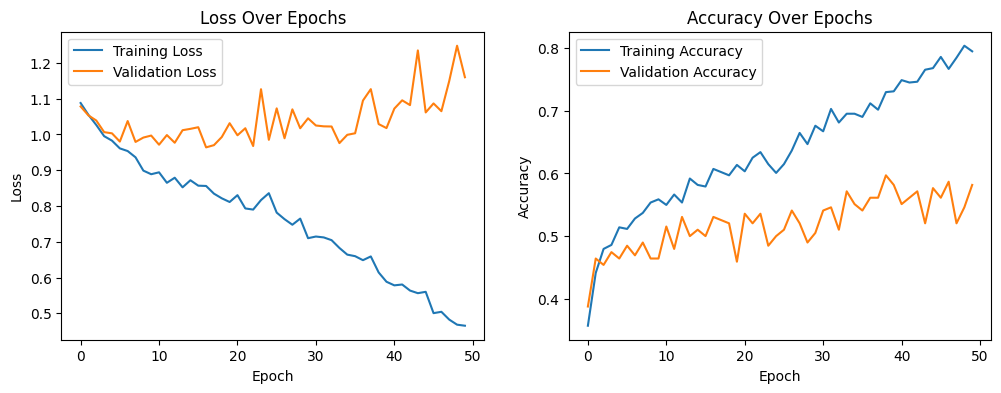

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


2025-05-05 10:41:56.370202: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


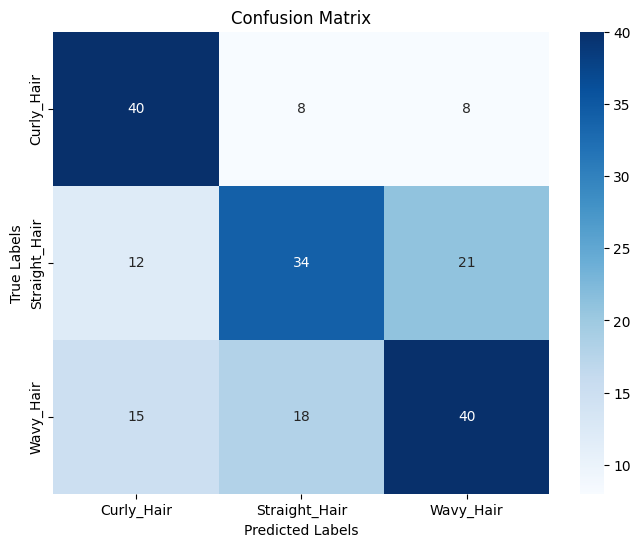

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.60      0.71      0.65        56
Straight_Hair       0.57      0.51      0.54        67
    Wavy_Hair       0.58      0.55      0.56        73

     accuracy                           0.58       196
    macro avg       0.58      0.59      0.58       196
 weighted avg       0.58      0.58      0.58       196



In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

### Experiment 2.2: Average Pooling
This experiment uses AveragePooling2D in Keras. An Average Pooling layer was added on each Conv2D layer.

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) # Added Average Pooling

model.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) # Added Average Pooling

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) # Added Average Pooling

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_with_average_pooling.png', show_shapes=True) #Changed filename
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.3545 - loss: 1.0983 - val_accuracy: 0.3571 - val_loss: 1.0880
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.4360 - loss: 1.0760 - val_accuracy: 0.4031 - val_loss: 1.0860
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.4848 - loss: 1.0126 - val_accuracy: 0.4439 - val_loss: 1.0719
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.5151 - loss: 0.9901 - val_accuracy: 0.4388 - val_loss: 1.0307
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.5265 - loss: 0.9396 - val_accuracy: 0.4592 - val_loss: 1.0056
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.5132 - loss: 0.9602 - val_accuracy: 0.5051 - val_loss: 0.9956
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.5304 - loss: 0.9175 - val_accur

#### Experiment 2.2 Evaluation Metrics Visualization

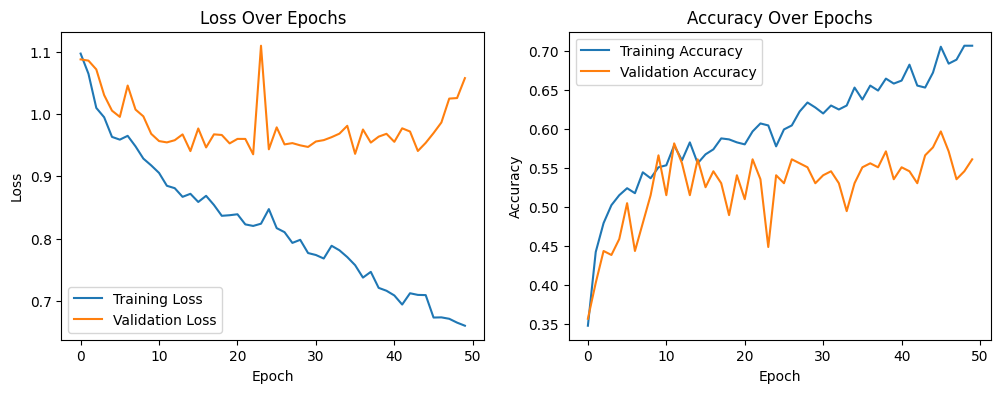

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


2025-05-05 10:45:32.786854: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


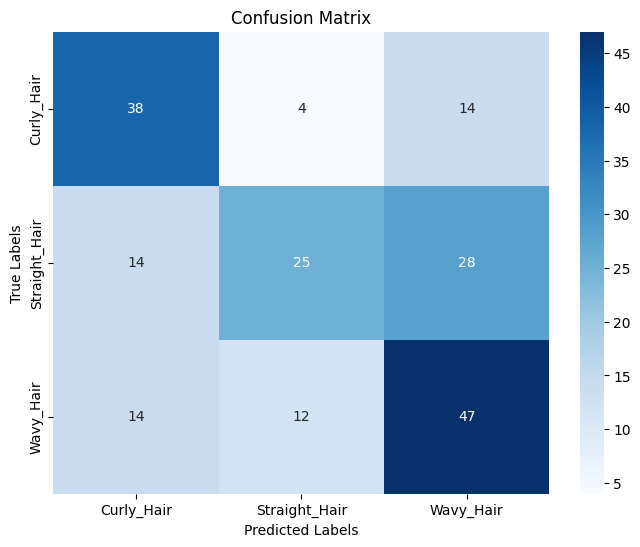

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.58      0.68      0.62        56
Straight_Hair       0.61      0.37      0.46        67
    Wavy_Hair       0.53      0.64      0.58        73

     accuracy                           0.56       196
    macro avg       0.57      0.57      0.56       196
 weighted avg       0.57      0.56      0.55       196



In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

### Experiment 2.3: Global Max Pooling
This experiment uses GlobalMaxPooling2D in Keras. A Global Max Pooling layer was added after the last Conv2D layer.

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalMaxPooling2D()) # Replaced with Global Max Pooling
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_with_global_max_pooling.png', show_shapes=True) #Changed filename
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)

Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.3821 - loss: 1.0984 - val_accuracy: 0.3878 - val_loss: 1.0973
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3929 - loss: 1.0973 - val_accuracy: 0.2908 - val_loss: 1.0987
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.3474 - loss: 1.0881 - val_accuracy: 0.3112 - val_loss: 1.0886
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.3791 - loss: 1.0627 - val_accuracy: 0.4286 - val_loss: 1.0621
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.4501 - loss: 1.0275 - val_accuracy: 0.4898 - val_loss: 1.0199
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.4817 - loss: 1.0171 - val_accuracy: 0.4694 - val_loss: 1.0082
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.5181 - loss: 0.9674 - val_accur

#### Experiment 2.3 Evaluation Metrics Visualization

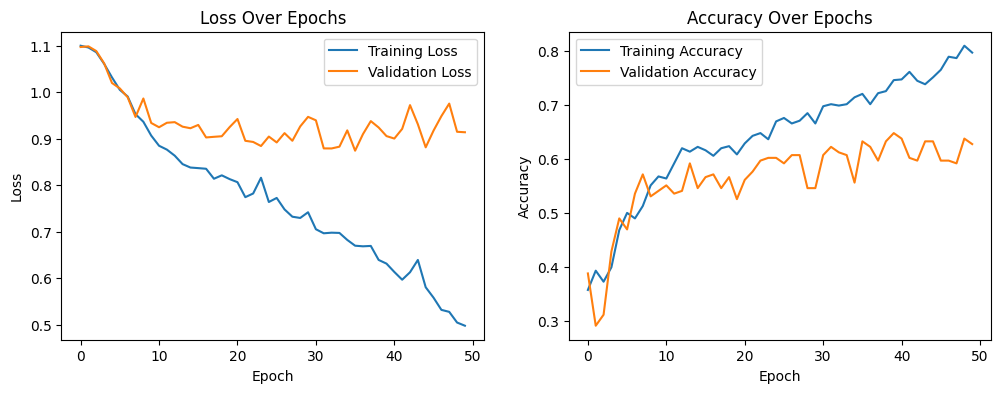

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


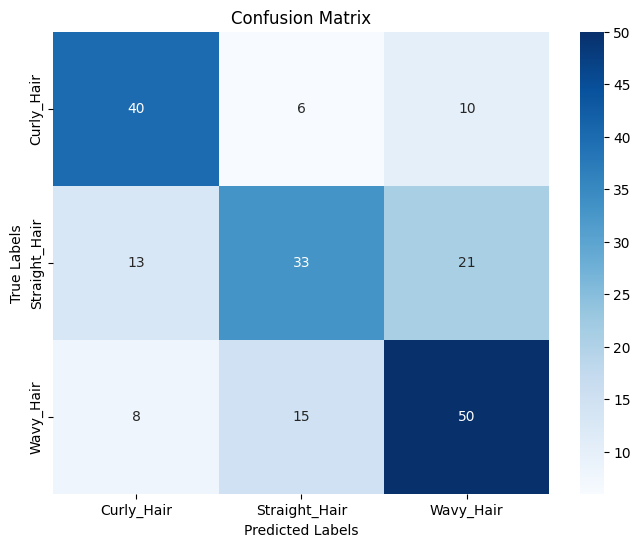

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.66      0.71      0.68        56
Straight_Hair       0.61      0.49      0.55        67
    Wavy_Hair       0.62      0.68      0.65        73

     accuracy                           0.63       196
    macro avg       0.63      0.63      0.63       196
 weighted avg       0.63      0.63      0.62       196



In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

### Experiment 2.4: Global Average Pooling
This experiment uses GlobalAveragePooling2D in Keras. A Global Average Pooling layer was added after the last Conv2D layer.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalAveragePooling2D()) # Retained Global Average Pooling
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_with_global_average_pooling.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.3631 - loss: 1.1022 - val_accuracy: 0.2857 - val_loss: 1.0971
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3565 - loss: 1.0845 - val_accuracy: 0.3418 - val_loss: 1.0784
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.4032 - loss: 1.0392 - val_accuracy: 0.3980 - val_loss: 1.0689
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.4504 - loss: 1.0234 - val_accuracy: 0.4541 - val_loss: 1.0505
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.4811 - loss: 1.0039 - val_accuracy: 0.4439 - val_loss: 1.0402
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.4596 - loss: 1.0037 - val_accuracy: 0.4490 - val_loss: 1.0362
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.4912 - loss: 0.9707 - val_accur

#### Experiment 2.4 Evaluation Metrics Visualization

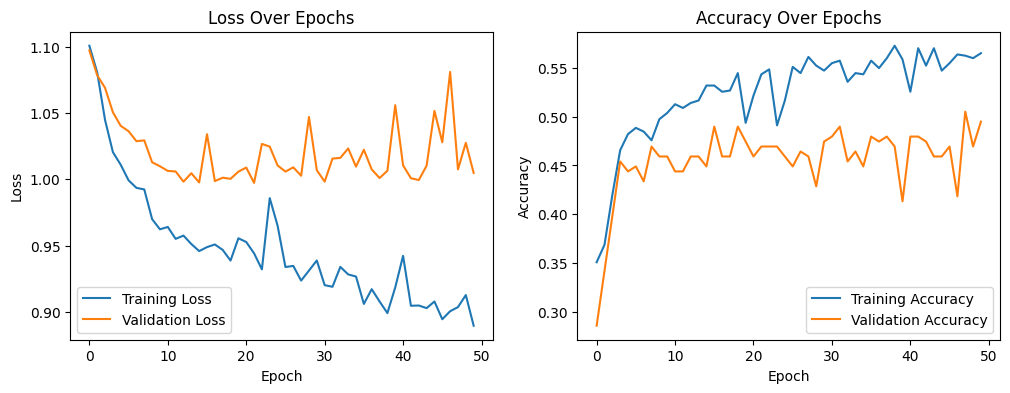

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


2025-05-05 10:50:56.688257: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


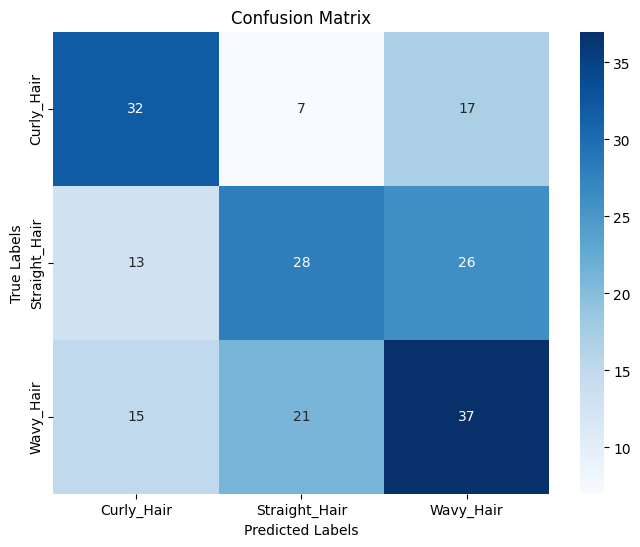

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.53      0.57      0.55        56
Straight_Hair       0.50      0.42      0.46        67
    Wavy_Hair       0.46      0.51      0.48        73

     accuracy                           0.49       196
    macro avg       0.50      0.50      0.50       196
 weighted avg       0.50      0.49      0.49       196



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

## Experiment #3: Changing Number of Filters

This experiment explores the effects of different number of filters. The normalized hair types dataset will be used for this experiment and Global Max Pooling will be used since it has the highest accuracy while maintaining its generalization. The following sub-experiments are the implementation of different number of filters. 
- Experiment 3.1: filters 2, 4, 8
- Experiment 3.2: filters 4, 6, 8
- Experiment 3.3: filters 8, 16, 32
- Experiment 3.4: filters 16, 32, 64
- Experiment 3.5: filters 32, 64, 128
- Experiment 3.6: filters 16, 16, 16

#### Experiment 3.1: filters 2, 4, 8
This experiment uses 2, 4, and 8 as the number of filters.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=2, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=4, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=8, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalMaxPooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_filter248.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.3276 - loss: 1.1044 - val_accuracy: 0.3469 - val_loss: 1.0990
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.3405 - loss: 1.0980 - val_accuracy: 0.2857 - val_loss: 1.1001
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3413 - loss: 1.0985 - val_accuracy: 0.2857 - val_loss: 1.1016
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.3469 - loss: 1.0980 - val_accuracy: 0.2857 - val_loss: 1.1007
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.3446 - loss: 1.0940 - val_accuracy: 0.4439 - val_loss: 1.0881
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.4170 - loss: 1.0744 - val_accuracy: 0.4337 - val_loss: 1.0687
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.4817 - loss: 1.0438 - val_accur

#### Experiment 3.1 Evaluation Metrics Visualization

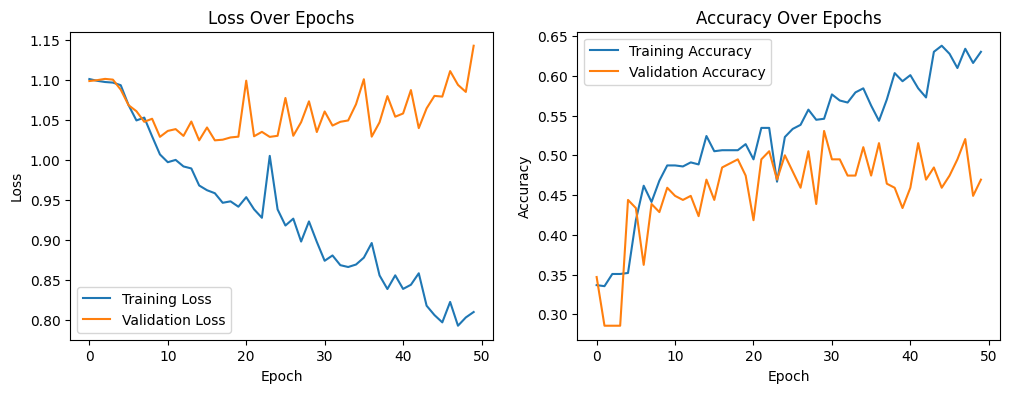

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


2025-05-05 10:55:09.566410: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


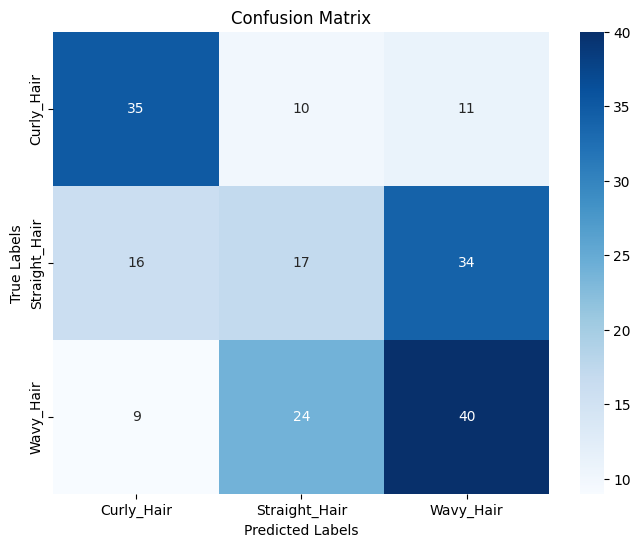

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.58      0.62      0.60        56
Straight_Hair       0.33      0.25      0.29        67
    Wavy_Hair       0.47      0.55      0.51        73

     accuracy                           0.47       196
    macro avg       0.46      0.48      0.47       196
 weighted avg       0.46      0.47      0.46       196



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

#### Experiment 3.2: filters 4, 6, 8
This experiment uses 4, 6, and 8 as the number of filters.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=6, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=8, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalMaxPooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_filter468.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.3839 - loss: 1.0909 - val_accuracy: 0.4541 - val_loss: 1.0733
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.4405 - loss: 1.0660 - val_accuracy: 0.4031 - val_loss: 1.0680
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.4376 - loss: 1.0313 - val_accuracy: 0.4133 - val_loss: 1.0714
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.4619 - loss: 1.0172 - val_accuracy: 0.4643 - val_loss: 1.0110
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.4722 - loss: 0.9908 - val_accuracy: 0.4745 - val_loss: 1.0211
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.4535 - loss: 1.0265 - val_accuracy: 0.4541 - val_loss: 1.0179
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.4896 - loss: 0.9907 - val_acc

#### Experiment 3.2 Evaluation Metrics Visualization

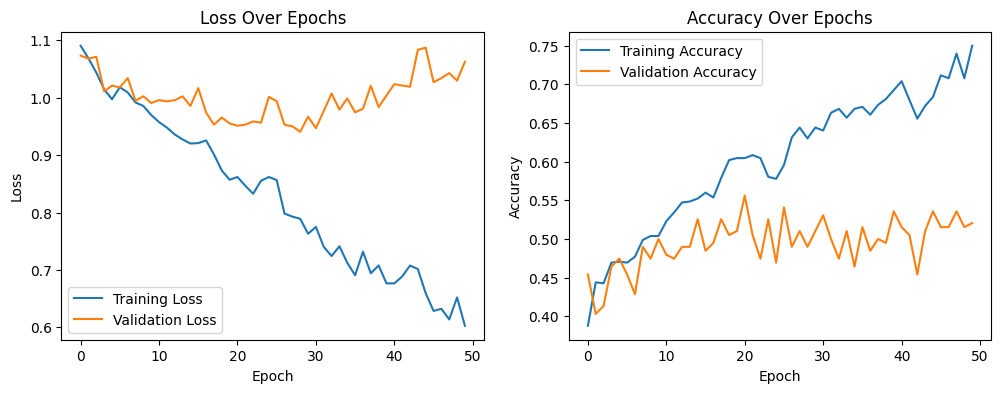

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


2025-05-05 10:58:37.539900: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


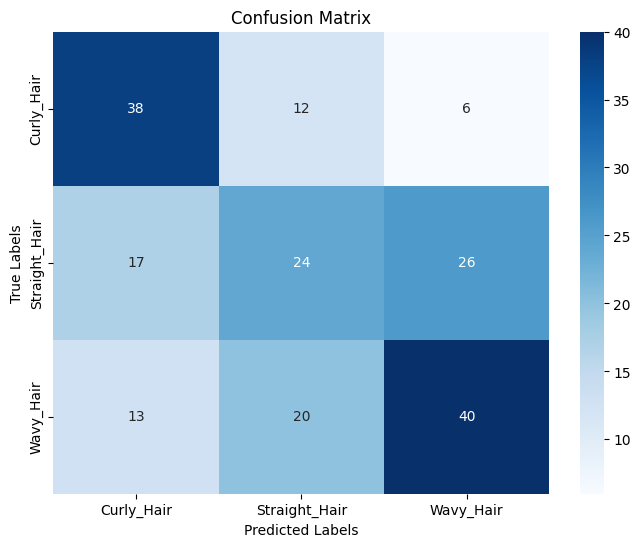

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.56      0.68      0.61        56
Straight_Hair       0.43      0.36      0.39        67
    Wavy_Hair       0.56      0.55      0.55        73

     accuracy                           0.52       196
    macro avg       0.51      0.53      0.52       196
 weighted avg       0.51      0.52      0.51       196



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

#### Experiment 3.3: filters 8, 16, 32
This experiment uses 8, 16, and 32 as the number of filters.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=8, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=32, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalMaxPooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_filter81632.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)

/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.3431 - loss: 1.1036 - val_accuracy: 0.2857 - val_loss: 1.1021
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.3843 - loss: 1.0916 - val_accuracy: 0.3418 - val_loss: 1.0910
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.4251 - loss: 1.0532 - val_accuracy: 0.4337 - val_loss: 1.0618
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.4741 - loss: 1.0279 - val_accuracy: 0.4337 - val_loss: 1.0167
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.4777 - loss: 1.0077 - val_accuracy: 0.4439 - val_loss: 1.0306
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.4257 - loss: 1.0364 - val_accuracy: 0.4490 - val_loss: 1.0321
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.4664 - loss: 0.9986 - va

#### Experiment 3.3 Evaluation Metrics Visualization

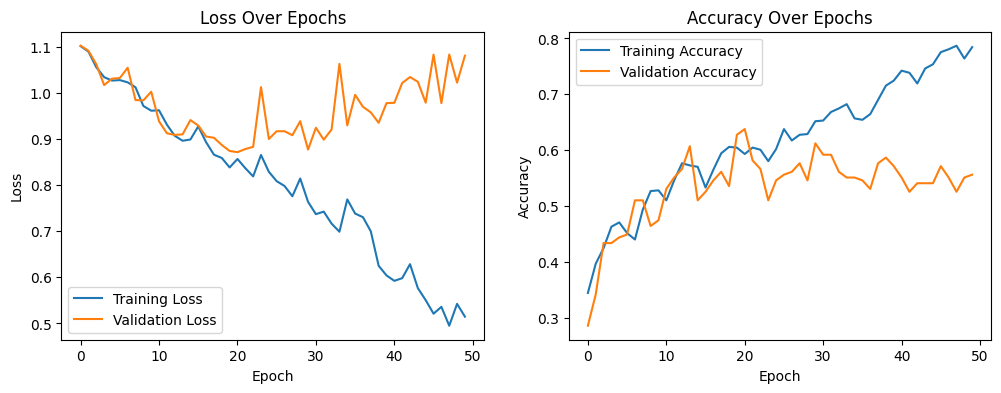

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


2025-05-05 11:02:17.108685: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


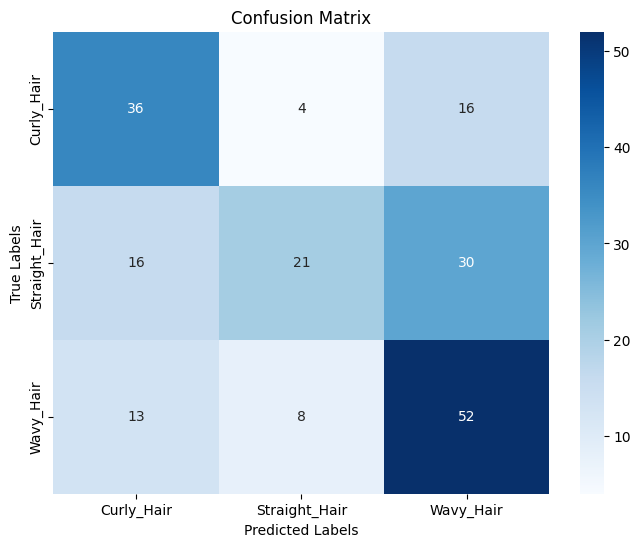

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.55      0.64      0.60        56
Straight_Hair       0.64      0.31      0.42        67
    Wavy_Hair       0.53      0.71      0.61        73

     accuracy                           0.56       196
    macro avg       0.57      0.56      0.54       196
 weighted avg       0.57      0.56      0.54       196



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

#### Experiment 3.4: filters 16, 32, 64
This experiment uses 16, 32, and 64 as the number of filters.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=32, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=64, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalMaxPooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_filter163264.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 192ms/step - accuracy: 0.3886 - loss: 1.0921 - val_accuracy: 0.4286 - val_loss: 1.0355
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.4173 - loss: 1.0572 - val_accuracy: 0.2857 - val_loss: 1.1401
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 197ms/step - accuracy: 0.3975 - loss: 1.0718 - val_accuracy: 0.4694 - val_loss: 1.0505
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - accuracy: 0.4929 - loss: 1.0183 - val_accuracy: 0.4490 - val_loss: 1.0089
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - accuracy: 0.4729 - loss: 0.9973 - val_accuracy: 0.4439 - val_loss: 1.0231
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step - accuracy: 0.4486 - loss: 1.0470 - val_accuracy: 0.4439 - val_loss: 1.0307
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.4617 - loss: 1.0035 - va

#### Experiment 3.4 Evaluation Metrics Visualization

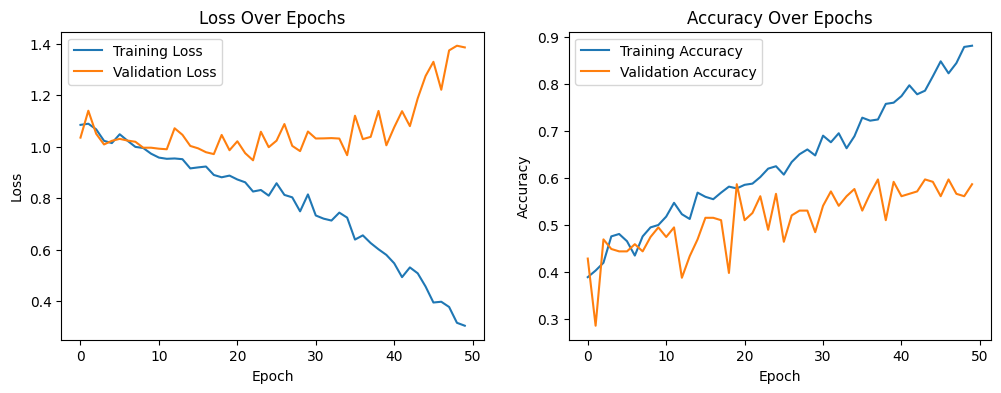

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


2025-05-05 11:07:42.352802: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


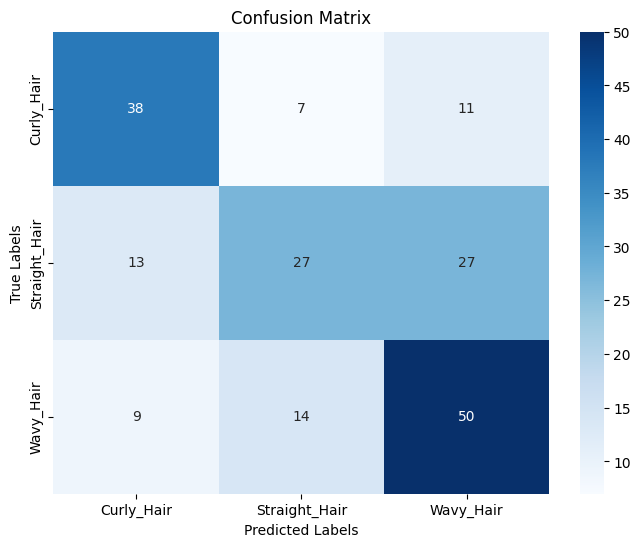

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.63      0.68      0.66        56
Straight_Hair       0.56      0.40      0.47        67
    Wavy_Hair       0.57      0.68      0.62        73

     accuracy                           0.59       196
    macro avg       0.59      0.59      0.58       196
 weighted avg       0.58      0.59      0.58       196



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

#### Experiment 3.5: filters 32, 64, 128
This experiment uses 32, 64, and 128 as the number of filters.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=32, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=64, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=128, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalMaxPooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_filter3264128.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 504ms/step - accuracy: 0.3534 - loss: 1.1103 - val_accuracy: 0.3061 - val_loss: 1.0969
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 488ms/step - accuracy: 0.3936 - loss: 1.0857 - val_accuracy: 0.4235 - val_loss: 1.0797
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 521ms/step - accuracy: 0.4436 - loss: 1.0561 - val_accuracy: 0.4439 - val_loss: 1.0750
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 560ms/step - accuracy: 0.5079 - loss: 1.0164 - val_accuracy: 0.4592 - val_loss: 1.0442
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 536ms/step - accuracy: 0.4605 - loss: 1.0278 - val_accuracy: 0.4541 - val_loss: 1.0354
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 588ms/step - accuracy: 0.4645 - loss: 1.0042 - val_accuracy: 0.4439 - val_loss: 1.0428
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 547ms/step - accuracy: 0.5222 - loss: 0.97

#### Experiment 3.5 Evaluation Metrics Visualization

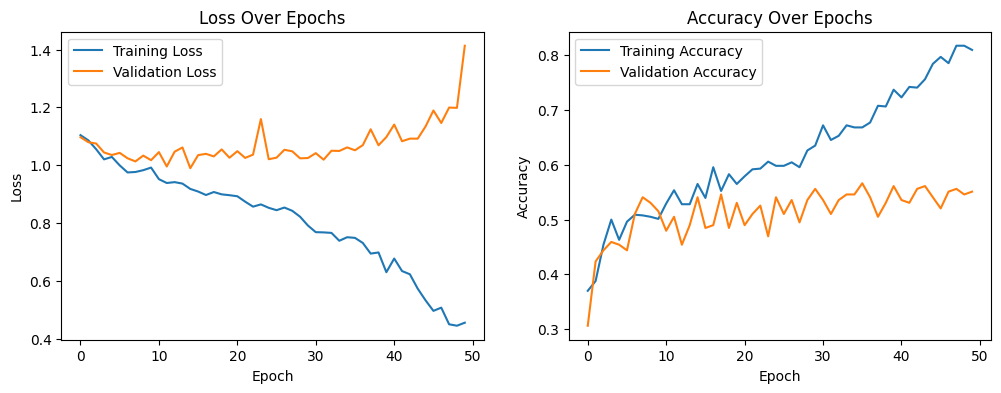

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


2025-05-05 11:20:54.334689: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


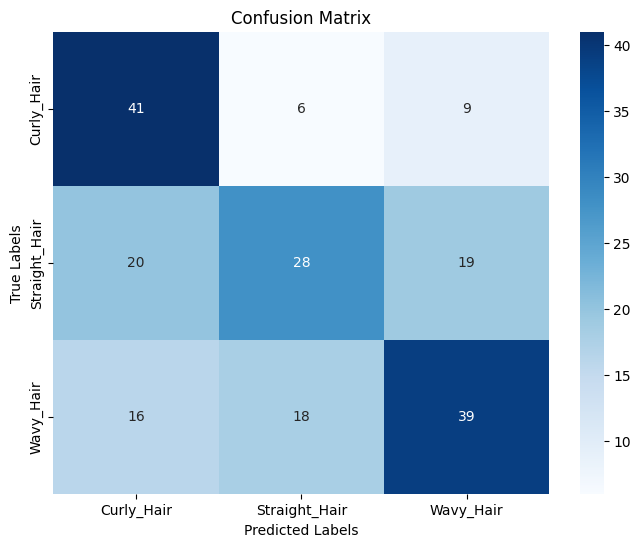

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.53      0.73      0.62        56
Straight_Hair       0.54      0.42      0.47        67
    Wavy_Hair       0.58      0.53      0.56        73

     accuracy                           0.55       196
    macro avg       0.55      0.56      0.55       196
 weighted avg       0.55      0.55      0.54       196



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

#### Experiment 3.6: filters 16, 16, 16
This experiment uses 16 as the number of filters.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalMaxPooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_filter161616.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - accuracy: 0.3613 - loss: 1.1080 - val_accuracy: 0.3061 - val_loss: 1.0986
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - accuracy: 0.3605 - loss: 1.0917 - val_accuracy: 0.3316 - val_loss: 1.0891
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - accuracy: 0.4031 - loss: 1.0611 - val_accuracy: 0.3878 - val_loss: 1.1036
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.4770 - loss: 1.0365 - val_accuracy: 0.4694 - val_loss: 1.0450
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.5060 - loss: 1.0151 - val_accuracy: 0.4745 - val_loss: 1.0485
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.4609 - loss: 1.0208 - val_accuracy: 0.5357 - val_loss: 1.0337
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.5244 - loss: 0.9916 - va

#### Experiment 3.6 Evaluation Metrics and Visualization

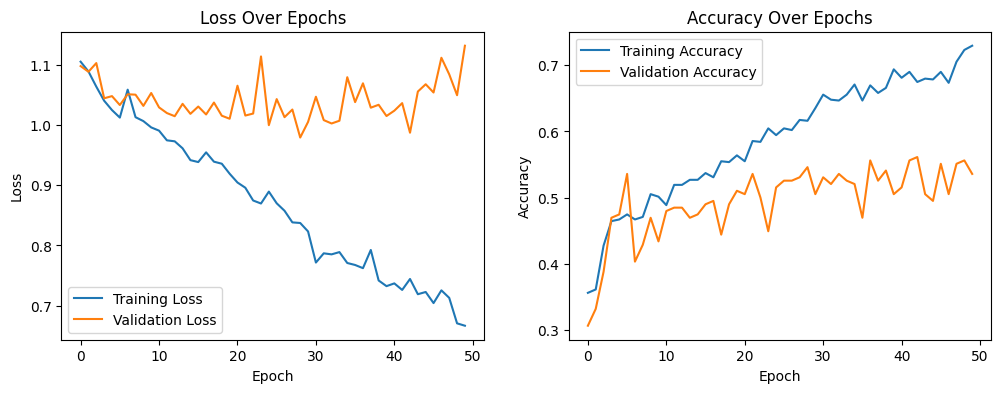

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


2025-05-05 11:24:40.962693: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


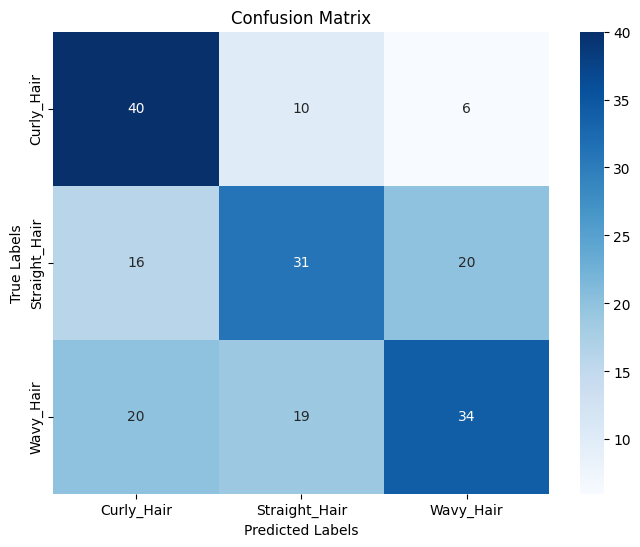

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.53      0.71      0.61        56
Straight_Hair       0.52      0.46      0.49        67
    Wavy_Hair       0.57      0.47      0.51        73

     accuracy                           0.54       196
    macro avg       0.54      0.55      0.54       196
 weighted avg       0.54      0.54      0.53       196



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

## Experiment #4: Changing Kernel Size

This experiment explores the effects of different kernel sizes. The normalized hair types dataset will be used for this experiment, Average Pooling will be used, and 16 as the number of all filters since it achieved better generalization compared to other number of filters. The following sub-experiments are the implementation of different kernel sizes.
- Experiment 4.1: Kernel Size (3,3), (5,5), (9,9)
- Experiment 4.2: Kernel Size (3,3), (3,3), (3,3)
- Experiment 4.3: Kernel Size (5,5), (5,5), (5,5)
- Experiment 4.4: Kernel Size (7,7), (5,5), (3,3)

#### Experiment 4.1: Kernel Size (3,3), (5,5), (9,9)
This experiment uses (3,3), (5,5), (9,9) as the kernel size.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(9,9), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalMaxPooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_kernel359.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 0.3595 - loss: 1.1033 - val_accuracy: 0.3724 - val_loss: 1.0969
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.3416 - loss: 1.0973 - val_accuracy: 0.4235 - val_loss: 1.0962
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.3759 - loss: 1.0934 - val_accuracy: 0.3061 - val_loss: 1.0961
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.4222 - loss: 1.0822 - val_accuracy: 0.4286 - val_loss: 1.0817
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.4966 - loss: 1.0473 - val_accuracy: 0.4694 - val_loss: 1.0419
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.4923 - loss: 1.0234 - val_accuracy: 0.5204 - val_loss: 0.9962
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.5703 - loss: 0.9506 - va

#### Experiment 4.1 Evaluation Metrics Visualization

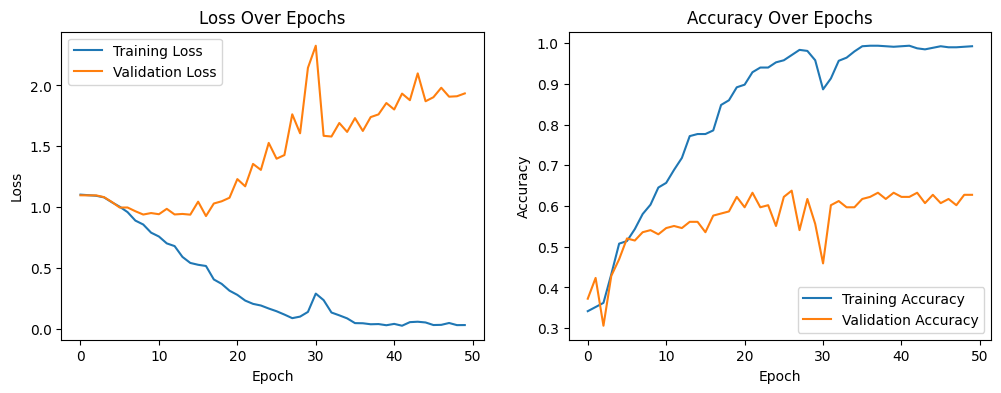

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


2025-05-05 11:29:54.434061: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


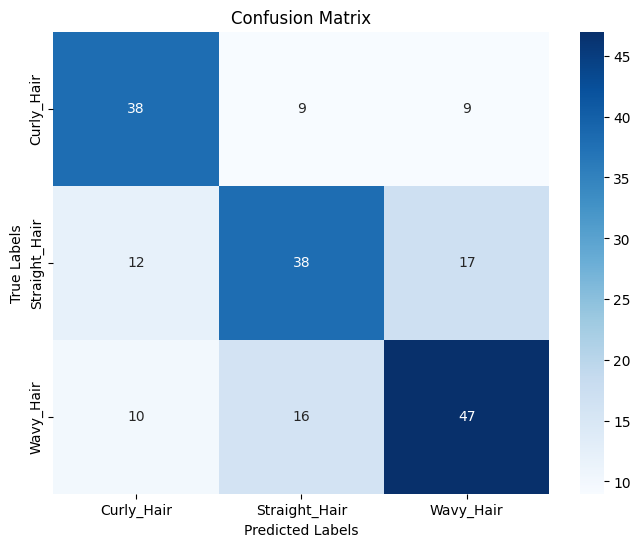

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.63      0.68      0.66        56
Straight_Hair       0.60      0.57      0.58        67
    Wavy_Hair       0.64      0.64      0.64        73

     accuracy                           0.63       196
    macro avg       0.63      0.63      0.63       196
 weighted avg       0.63      0.63      0.63       196



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

#### Experiment 4.2: Kernel Size (3,3), (3,3), (3,3)
This experiment uses (3,3) as the kernel size of all Conv2D layers.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalMaxPooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_kernel333.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.3659 - loss: 1.0959 - val_accuracy: 0.4337 - val_loss: 1.0964
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.3969 - loss: 1.0955 - val_accuracy: 0.2959 - val_loss: 1.0973
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.3472 - loss: 1.0910 - val_accuracy: 0.2959 - val_loss: 1.0941
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.3755 - loss: 1.0869 - val_accuracy: 0.2857 - val_loss: 1.0989
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.3775 - loss: 1.0825 - val_accuracy: 0.4388 - val_loss: 1.0798
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.4162 - loss: 1.0788 - val_accuracy: 0.4694 - val_loss: 1.0644
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.4420 - loss: 1.0574 - val_accur

#### Experiment 4.2 Evaluation Metrics Visualization

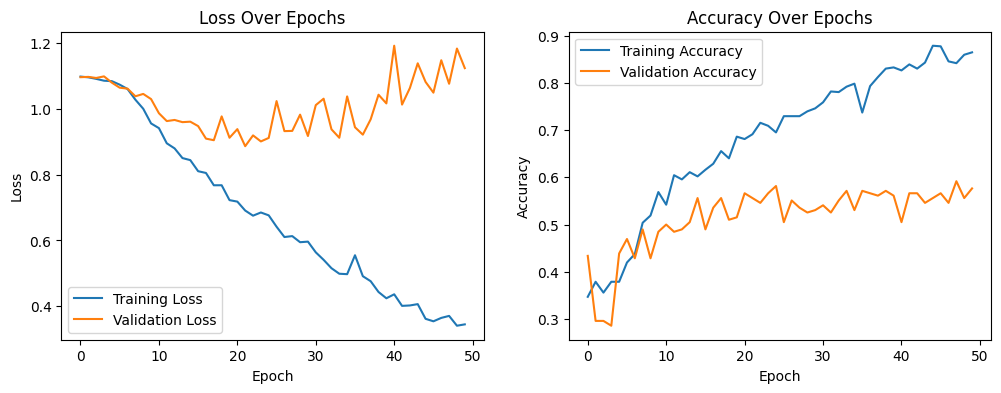

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


2025-05-05 11:32:27.227035: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


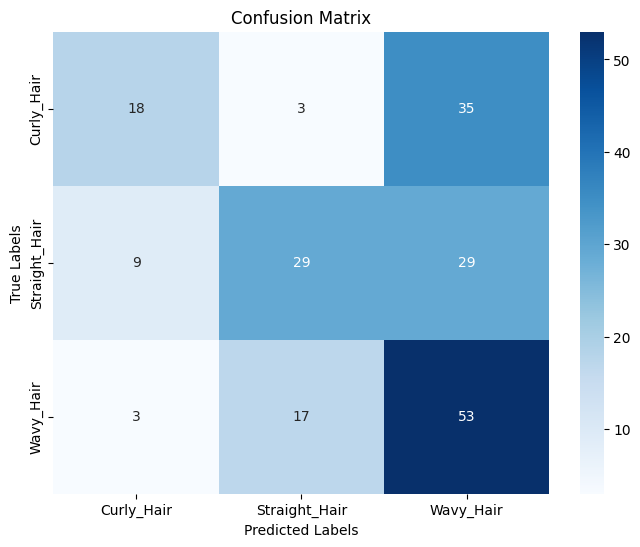

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.60      0.32      0.42        56
Straight_Hair       0.59      0.43      0.50        67
    Wavy_Hair       0.45      0.73      0.56        73

     accuracy                           0.51       196
    macro avg       0.55      0.49      0.49       196
 weighted avg       0.54      0.51      0.50       196



In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

#### Experiment 4.3: Kernel Size (5,5), (5,5), (5,5)
This experiment uses (5,5) as the kernel size of all Conv2D layers.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalMaxPooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_kernel555.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.3363 - loss: 1.1006 - val_accuracy: 0.2857 - val_loss: 1.0994
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.3515 - loss: 1.0968 - val_accuracy: 0.2857 - val_loss: 1.1004
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.3412 - loss: 1.0939 - val_accuracy: 0.2908 - val_loss: 1.0956
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.3773 - loss: 1.0863 - val_accuracy: 0.4745 - val_loss: 1.0731
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.4568 - loss: 1.0634 - val_accuracy: 0.5204 - val_loss: 1.0499
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.4139 - loss: 1.0733 - val_accuracy: 0.4541 - val_loss: 1.0401
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.5074 - loss: 1.0314 - val_accu

#### Experiment 4.3 Evaluation Metrics Visualization

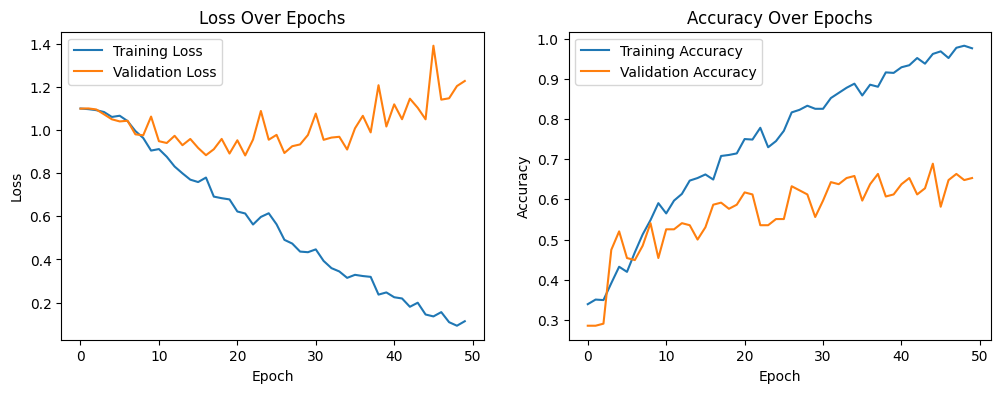

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


2025-05-05 11:36:53.250509: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


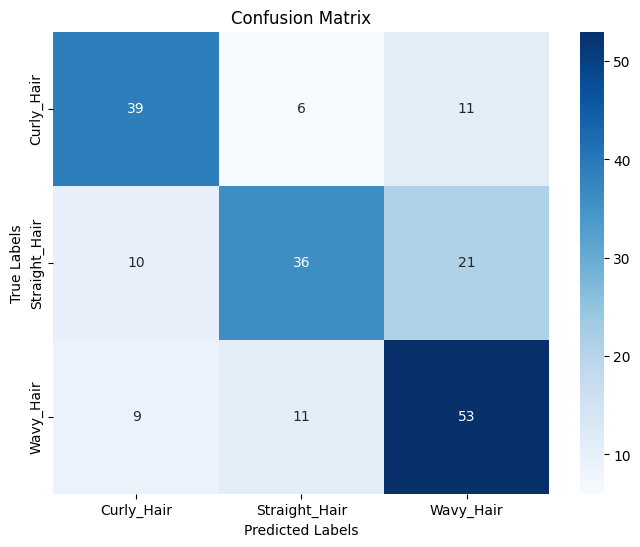

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.67      0.70      0.68        56
Straight_Hair       0.68      0.54      0.60        67
    Wavy_Hair       0.62      0.73      0.67        73

     accuracy                           0.65       196
    macro avg       0.66      0.65      0.65       196
 weighted avg       0.66      0.65      0.65       196



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

#### Experiment 4.4: Kernel Size (7,7), (5,5), (3,3)
This experiment uses (7,7), (5,5) and (3,3) as the kernel size.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(7,7), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalMaxPooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_kernel753.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.3336 - loss: 1.0987 - val_accuracy: 0.2857 - val_loss: 1.0997
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.3515 - loss: 1.0967 - val_accuracy: 0.2857 - val_loss: 1.0990
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.3413 - loss: 1.0933 - val_accuracy: 0.2857 - val_loss: 1.0975
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.3676 - loss: 1.0852 - val_accuracy: 0.4796 - val_loss: 1.0608
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.4544 - loss: 1.0528 - val_accuracy: 0.3980 - val_loss: 1.0643
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.4542 - loss: 1.0408 - val_accuracy: 0.3724 - val_loss: 1.0528
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.4722 - loss: 1.0155 - val_accur

#### Experiment 4.4 Evaluation Metrics Visualization

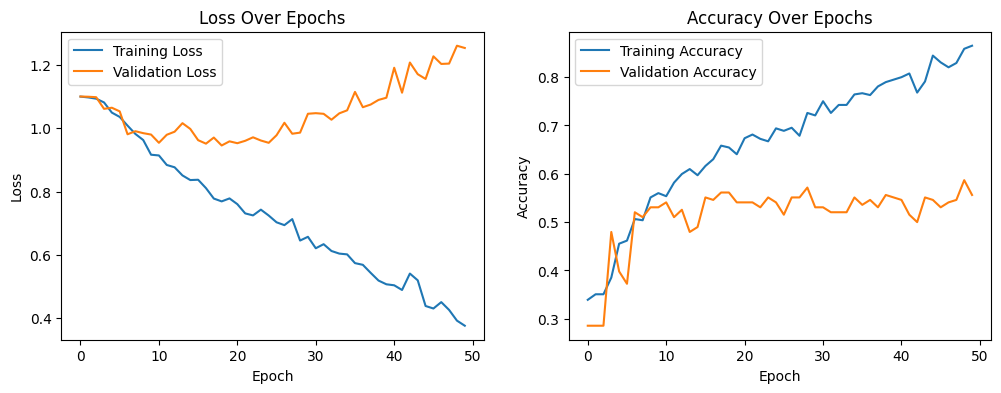

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


2025-05-05 11:41:59.106264: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


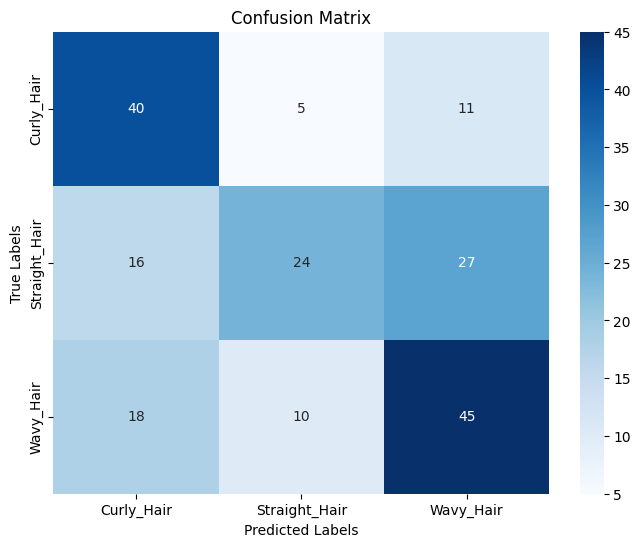

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.54      0.71      0.62        56
Straight_Hair       0.62      0.36      0.45        67
    Wavy_Hair       0.54      0.62      0.58        73

     accuracy                           0.56       196
    macro avg       0.57      0.56      0.55       196
 weighted avg       0.57      0.56      0.55       196



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

## Experiment #5: Changing Learning Rate

This experiment explores the effects of different learning rate. The normalized hair types dataset will be used for this experiment, Average Pooling will be used,16 as the number of all filters, and (5,5) as the kernel size in all Conv2D layers since it achieved better generalization than other kernel size. The following sub-experiments are the implementation of different learning rate.
- Experiment 5.1 Learning Rate 1e-2
- Experiment 5.2 Learning Rate 1e-4
- Experiment 5.3 Learning Rate 1e-5

#### Experiment 5.1: Learning Rate 1e-2
This experiment uses 1e-2 as the learning rate.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalMaxPooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_lr1e2.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-2),  # Changed learning rate
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.3200 - loss: 1.1408 - val_accuracy: 0.3724 - val_loss: 1.0960
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.3233 - loss: 1.1005 - val_accuracy: 0.2857 - val_loss: 1.1054
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.3437 - loss: 1.0990 - val_accuracy: 0.2806 - val_loss: 1.1059
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3628 - loss: 1.0959 - val_accuracy: 0.2857 - val_loss: 1.1075
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.3464 - loss: 1.0988 - val_accuracy: 0.3010 - val_loss: 1.1027
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.3814 - loss: 1.0962 - val_accuracy: 0.3418 - val_loss: 1.0985
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.3963 - loss: 1.0760 - val_accur

#### Experiment 5.1 Evaluation Metrics Visualization

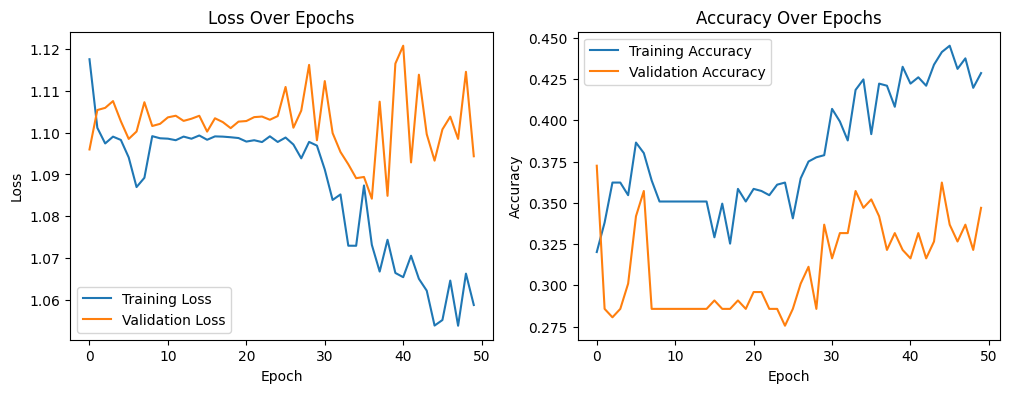

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


2025-05-05 11:45:26.753453: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


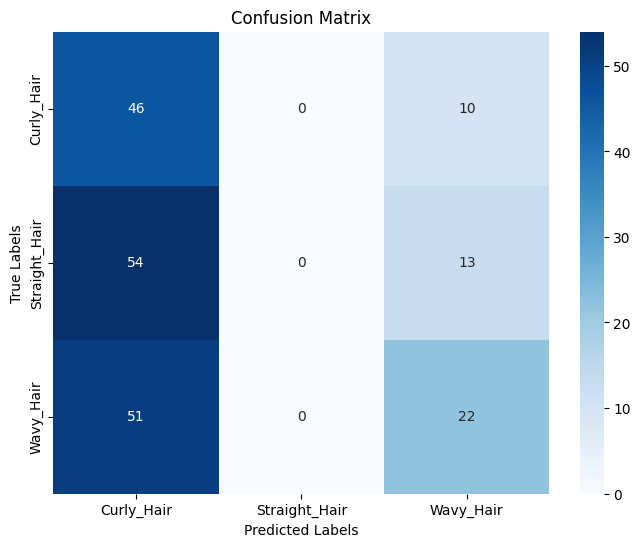

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.30      0.82      0.44        56
Straight_Hair       0.00      0.00      0.00        67
    Wavy_Hair       0.49      0.30      0.37        73

     accuracy                           0.35       196
    macro avg       0.26      0.37      0.27       196
 weighted avg       0.27      0.35      0.27       196



/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

#### Experiment 5.2: Learning Rate 1e-4
This experiment uses 1e-4 as the learning rate.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalMaxPooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_lr1e4.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),  # Changed learning rate
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.3108 - loss: 1.0982 - val_accuracy: 0.2857 - val_loss: 1.0997
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.3539 - loss: 1.0955 - val_accuracy: 0.2857 - val_loss: 1.0996
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.3425 - loss: 1.0944 - val_accuracy: 0.2857 - val_loss: 1.0991
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.3489 - loss: 1.0935 - val_accuracy: 0.2806 - val_loss: 1.0989
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.3504 - loss: 1.0927 - val_accuracy: 0.2857 - val_loss: 1.0990
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3620 - loss: 1.0914 - val_accuracy: 0.2806 - val_loss: 1.0978
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3765 - loss: 1.0867 - val_accur

#### Experiment 5.2 Evaluation Metrics Visualization

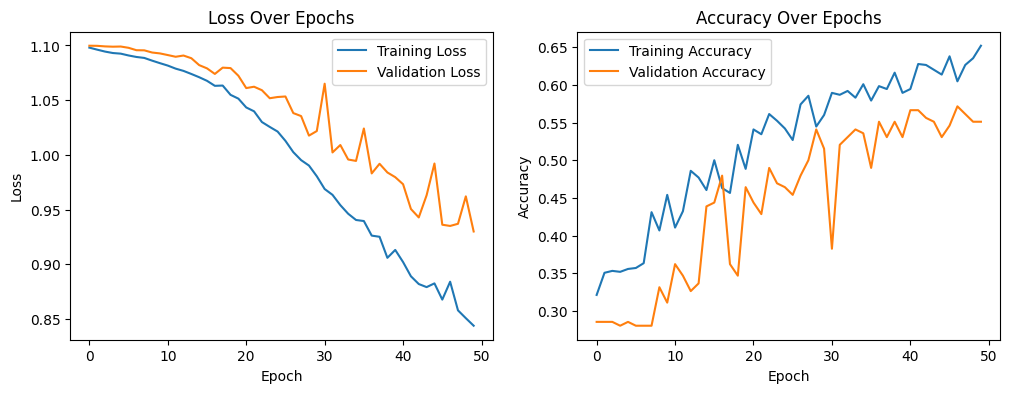

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


2025-05-05 11:48:10.364000: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


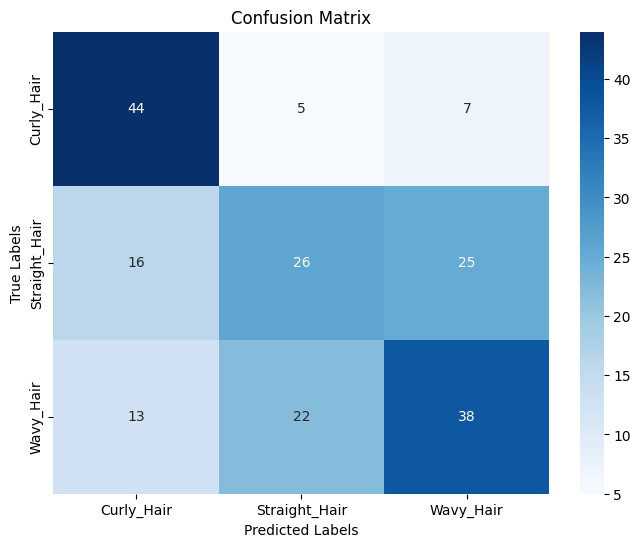

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.60      0.79      0.68        56
Straight_Hair       0.49      0.39      0.43        67
    Wavy_Hair       0.54      0.52      0.53        73

     accuracy                           0.55       196
    macro avg       0.55      0.56      0.55       196
 weighted avg       0.54      0.55      0.54       196



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

#### Experiment 5.3: Learning Rate 1e-5
This experiment uses 1e-5 as the learning rate.

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalMaxPooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_lr1e5.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # Changed learning rate
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)

Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.3631 - loss: 1.0954 - val_accuracy: 0.2857 - val_loss: 1.1089
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.3515 - loss: 1.0966 - val_accuracy: 0.2857 - val_loss: 1.1076
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.3413 - loss: 1.0998 - val_accuracy: 0.2857 - val_loss: 1.1068
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.3469 - loss: 1.0956 - val_accuracy: 0.2857 - val_loss: 1.1060
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.3444 - loss: 1.0951 - val_accuracy: 0.2857 - val_loss: 1.1054
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.3581 - loss: 1.0925 - val_accuracy: 0.2857 - val_loss: 1.1051
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3701 - loss: 1.0928 - val_accur

#### Experiment 5.3 Evaluation Metrics Visualization

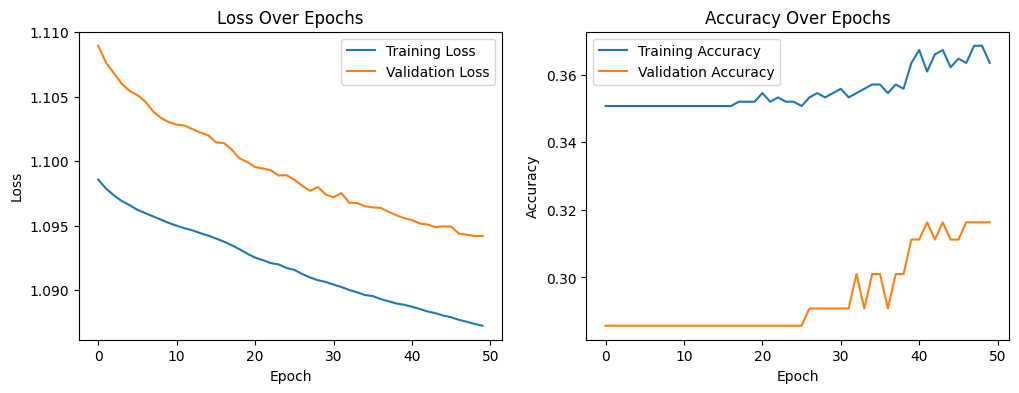

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


2025-05-05 11:51:33.210799: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


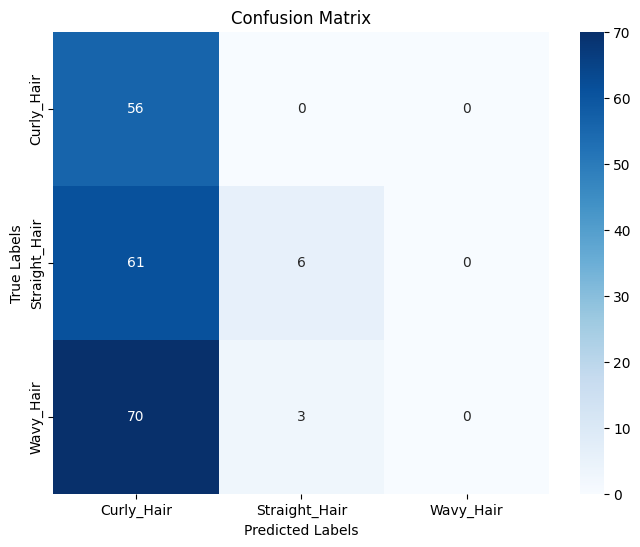

Classification Report:
               precision    recall  f1-score   support

   Curly_Hair       0.30      1.00      0.46        56
Straight_Hair       0.67      0.09      0.16        67
    Wavy_Hair       0.00      0.00      0.00        73

     accuracy                           0.32       196
    macro avg       0.32      0.36      0.21       196
 weighted avg       0.31      0.32      0.19       196



/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Line Plots for Loss and Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Confusion Matrix
# Get predictions for the validation set
y_true = []
y_pred = []
for x_batch, y_batch in val_ds:
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred.extend(tf.argmax(model.predict(x_batch), axis=1).numpy())

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=val_ds.class_names,
                yticklabels=val_ds.class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_ds.class_names))

***
## Predicting the Image with the Best Model
In this section, the best model will be used based from the previous experiments to predict the image. The normalized hair types dataset will be used, Global Max Pooling will be used, 16 as the number of all filters, (5,5) as the kernel size in all Conv2D layers, and le-4 as the learning rate will be used.

### Predicting Curly Hair

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalMaxPooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)

img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.3631 - loss: 1.0969 - val_accuracy: 0.2857 - val_loss: 1.1033
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.3515 - loss: 1.0966 - val_accuracy: 0.2857 - val_loss: 1.1014
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.3413 - loss: 1.0959 - val_accuracy: 0.2857 - val_loss: 1.1015
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.3469 - loss: 1.0957 - val_accuracy: 0.2857 - val_loss: 1.1007
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.3444 - loss: 1.0949 - val_accuracy: 0.2857 - val_loss: 1.1005
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.3581 - loss: 1.0924 - val_accuracy: 0.2857 - val_loss: 1.1003
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.3701 - loss: 1.0875 - val_accur

### Predicting Straight Hair

In [2]:
img = keras.preprocessing.image.load_img(
    "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/hair_types/Straight_Hair/3d0ed46487fd72bb3dbda1161897ac49.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
This image is 0.41 percent curly hair, 0.36 percent straight hair, and 0.22 percent wavy hair.


### Predicting Wavy Hair

In [3]:
img = keras.preprocessing.image.load_img(
    "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/hair_types/Wavy_Hair/9cc8d5985f0a8c2bc333059dbe3b5bcb.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
This image is 0.33 percent curly hair, 0.40 percent straight hair, and 0.27 percent wavy hair.


### Predicting Jan Vincent Elleazar's Hair Type

In [4]:
img = keras.preprocessing.image.load_img(
    "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/944df86d-8024-48fb-ac22-a18356dd9f81.jpeg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
This image is 0.13 percent curly hair, 0.48 percent straight hair, and 0.39 percent wavy hair.


***
## Other Experiment
Out of curiosity, this experiment utilizes the Gaussian Blur hair types dataset, as oppose to earlier with the mixture of Laplacian Filter, in order to determine if this filter would make the model perform better.

In [39]:
data_dir = "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types"  # Input directory
output_dir = "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/gaussianblur_hair_types"  # Output directory

# Create the output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for root, _, files in os.walk(data_dir):
    for filename in files:
        filepath = os.path.join(root, filename)
        try:
            # Read the image using the full file path
            img = cv.imread(filepath)

            # Check if the image was loaded successfully
            if img is not None:
                # Apply Gaussian Blur
                img_blurred = cv.GaussianBlur(img, (5, 5), 0)  # Kernel size 5x5, sigma = 0

                # Construct the output file paths.
                relative_path = os.path.relpath(filepath, data_dir)

                # Output filepath
                output_filepath = os.path.join(output_dir, relative_path)

                # Ensure the output directory exists
                output_dir_for_file = os.path.dirname(output_filepath)
                if not os.path.exists(output_dir_for_file):
                    os.makedirs(output_dir_for_file)

                cv.imwrite(output_filepath, img_blurred)

                print(f"Processed and saved: {output_filepath}")

            else:
                print(f"Error loading image: {filepath}")

        except Exception as e:
            print(f"An error occurred with {filepath}: {str(e)}")

Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/gaussianblur_hair_types/Wavy_Hair/images282.jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/gaussianblur_hair_types/Wavy_Hair/images26.jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/gaussianblur_hair_types/Wavy_Hair/images32.jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/gaussianblur_hair_types/Wavy_Hair/long-hairstyles-for-indian-men-6(1).jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/gaussianblur_hair_types/Wavy_Hair/image3(1).jpeg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/gaussianblur_hair_types/Wavy_Hair/images308.jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/gaussianblur_hair_types/Wavy_Hair/images320.jpg
Pr

#### Using the same best model from earlier to predict curly hair.

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "gaussianblur_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "gaussianblur_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalMaxPooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)

img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.2991 - loss: 1.1006 - val_accuracy: 0.3571 - val_loss: 1.0956
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.3400 - loss: 1.0970 - val_accuracy: 0.4184 - val_loss: 1.0958
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.4609 - loss: 1.0947 - val_accuracy: 0.3673 - val_loss: 1.0952
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.3906 - loss: 1.0935 - val_accuracy: 0.3673 - val_loss: 1.0941
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.3916 - loss: 1.0913 - val_accuracy: 0.3418 - val_loss: 1.0932
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.3836 - loss: 1.0887 - val_accuracy: 0.3469 - val_loss: 1.0914
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.4050 - loss: 1.0821 - val_accur

***
# Results, Analysis, and Conclusion
Please refer to our written report for the discussion of the findings of this laboratory exercise. Thank you :)